In [1]:
import sqlite3

# creating file path
dbfile = 'experiment_results.db'
# Create a SQL connection to our SQLite database
con = sqlite3.connect(dbfile)

# creating cursor
cur = con.cursor()

# reading all table names
table_list = [a for a in cur.execute("SELECT name FROM sqlite_master WHERE type = 'table'")]
# here is you table list
print(table_list)

# Be sure to close the connection
con.close()

[('experiments',), ('sqlite_sequence',)]


In [3]:

import sqlite3
import pandas as pd

# 1. Connect to the database
conn = sqlite3.connect('experiment_results.db')

# 2. Run the query and load into a DataFrame
df = pd.read_sql_query("SELECT * FROM experiments", conn)

# 3. Close the connection
conn.close()

# Display the first few rows
print(df.head())

   id                 original_NL                  original_LTL  \
0   1  keep apple until drop pear  "keep(apple)" U "drop(pear)"   
1   2  keep apple until drop pear  "keep(apple)" U "drop(pear)"   
2   3  keep apple until drop pear  "keep(apple)" U "drop(pear)"   
3   4  keep apple until drop pear  "keep(apple)" U "drop(pear)"   
4   5  keep apple until drop pear  "keep(apple)" U "drop(pear)"   

                 Spot_LTL                          APs prompt_type  \
0  keep_apple U drop_pear  ['drop_pear', 'keep_apple']       BASIC   
1  keep_apple U drop_pear  ['drop_pear', 'keep_apple']       BASIC   
2  keep_apple U drop_pear  ['drop_pear', 'keep_apple']       BASIC   
3  keep_apple U drop_pear  ['drop_pear', 'keep_apple']       BASIC   
4  keep_apple U drop_pear  ['drop_pear', 'keep_apple']       BASIC   

   temperature     status  started_at  \
0          0.0  COMPLETED         NaN   
1          0.1  COMPLETED         NaN   
2          0.2  COMPLETED         NaN   
3          0

In [8]:
df.T[0]['temperature']

0.0

--- Row-Level Summary Statistics by Temperature ---
    temperature  mean_pct  std_pct  median_pct  count
0           0.0      3.49     3.19         5.0  43008
1           0.1      4.97     5.80         5.0  43008
2           0.2      6.88     9.21         5.0  43008
3           0.3      9.31    12.83         5.0  43008
4           0.4     11.62    15.97         5.0  43008
5           0.5     14.04    18.93        10.0  43008
6           0.6     16.57    21.53        10.0  43008
7           0.7     19.04    23.99        10.0  43008
8           0.8     21.54    26.30        10.0  43008
9           0.9     24.02    28.34        15.0  43008
10          1.0     26.49    30.17        15.0  43008


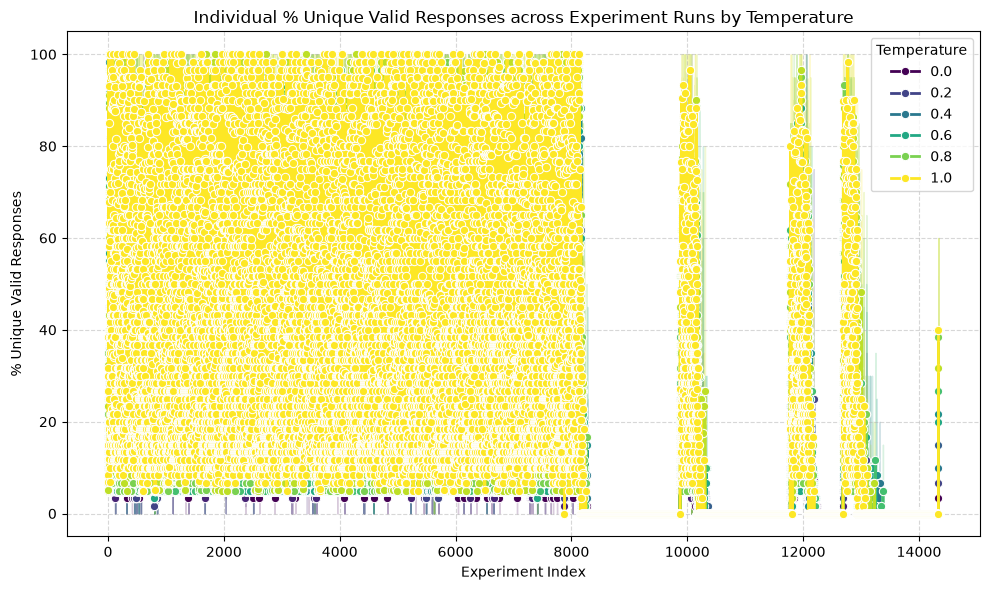

/tmp/ipykernel_22107/55650264.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


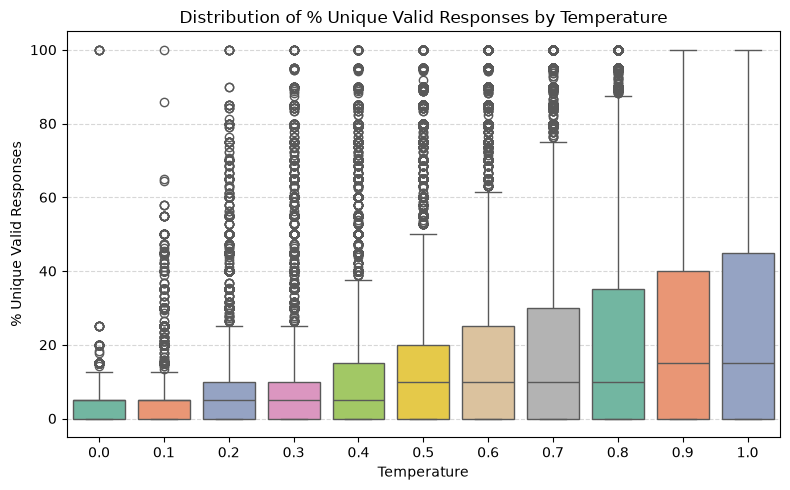

In [ ]:
import sqlite3
import json
import pandas as pd
import spot
import matplotlib.pyplot as plt
import seaborn as sns

def process_result_output(json_str):
    """
    Parses 'result_output' JSON string, keeps entries with valid spot.formula syntax,
    and returns metadata list and counts.
    """
    if not json_str or pd.isna(json_str):
        return pd.Series([[], 0, 0])
    
    try:
        items = json.loads(json_str)
    except json.JSONDecodeError:
        return pd.Series([[], 0, 0])
    
    cleaned_data = []
    valid_responses = []
    
    for entry in items:
        resp = entry.get("Response", "")
        
        try:
            spot.formula(resp)
            cleaned_data.append(entry)
            valid_responses.append(resp)
        except Exception:
            continue
            
    unique_count = len(set(valid_responses))
    total_count = len(cleaned_data)
    
    return pd.Series([cleaned_data, unique_count, total_count])

# --- Pipeline Execution ---

# 1. Load data
conn = sqlite3.connect('experiment_results.db')
df = pd.read_sql_query("SELECT * FROM experiments", conn)
conn.close()

# 2. Extract cleaned list and counts per experiment row
df[['cleaned_result_output', 'num_unique_valid_responses', 'num_valid_responses']] = (
    df['result_output'].apply(process_result_output)
)

# 3. Calculate individual percentage per row/experiment
df['pct_unique_valid'] = (
    (df['num_unique_valid_responses'] / df['num_valid_responses']) * 100
).fillna(0).round(2)

# 4. Group by temperature to see individual percentage statistics (Mean, Median, Std)
row_level_summary = df.groupby('temperature')['pct_unique_valid'].agg(
    mean_pct='mean',
    std_pct='std',
    median_pct='median',
    count='count'
).reset_index().round(2)

print("--- Row-Level Summary Statistics by Temperature ---")
print(row_level_summary)

# 5. Visualization: Plotting curves per temperature

# # Plot 1: Trend of % Unique Valid Responses across Experiment Indices per Temperature
# plt.figure(figsize=(10, 6))
# sns.lineplot(
#     data=df,
#     x='experiment_index',
#     y='pct_unique_valid',
#     hue='temperature',
#     palette='viridis',
#     marker='o',
#     linewidth=2
# )

# plt.title('Individual % Unique Valid Responses across Experiment Runs by Temperature', fontsize=12)
# plt.xlabel('Experiment Index', fontsize=10)
# plt.ylabel('% Unique Valid Responses', fontsize=10)
# plt.legend(title='Temperature', loc='best')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

# # Plot 2: Distribution / Mean Curve across Temperatures
# plt.figure(figsize=(8, 5))
# sns.boxplot(
#     data=df,
#     x='temperature',
#     y='pct_unique_valid',
#     palette='Set2'
# )

# plt.title('Distribution of % Unique Valid Responses by Temperature', fontsize=12)
# plt.xlabel('Temperature', fontsize=10)
# plt.ylabel('% Unique Valid Responses', fontsize=10)
# plt.grid(True, axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

Successfully saved new columns to SQLite database!


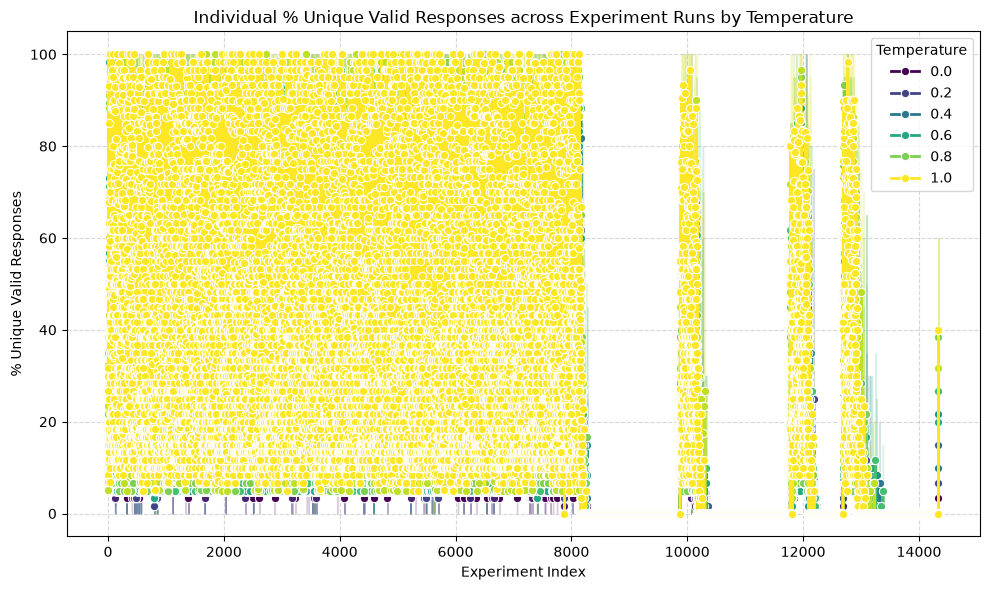

In [ ]:
import sqlite3
import json
import pandas as pd
import spot
import matplotlib.pyplot as plt
import seaborn as sns

def process_result_output(json_str):
    """
    Parses 'result_output' JSON string, keeps entries with valid spot.formula syntax,
    and returns metadata list and counts.
    """
    if not json_str or pd.isna(json_str):
        return pd.Series([[], 0, 0, 0])
    
    try:
        items = json.loads(json_str)
    except json.JSONDecodeError:
        return pd.Series([[], 0, 0, 0])
    
    cleaned_data = []
    valid_responses = []
    total_raw_count = len(items)
    
    for entry in items:
        resp = entry.get("Response", "")
        
        try:
            spot.formula(resp)
            cleaned_data.append(entry)
            valid_responses.append(resp)
        except Exception:
            continue
            
    num_valid = len(cleaned_data)
    num_unique_valid = len(set(valid_responses))
    num_invalid = total_raw_count - num_valid
    
    return pd.Series([cleaned_data, num_unique_valid, num_valid, num_invalid])

# --- 1. Load Data ---
db_path = 'experiment_results.db'
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM experiments", conn)

# --- 2. Extract Metrics & New Columns ---
df[[
    'cleaned_result_output_data', 
    'num_unique_valid_responses', 
    'num_valid_responses', 
    'num_invalid_responses'
]] = df['result_output'].apply(process_result_output)

# Calculate individual percentage per row/experiment
df['pct_unique_valid'] = (
    (df['num_unique_valid_responses'] / df['num_valid_responses']) * 100
).fillna(0).round(2)

# Convert cleaned list of dicts back to JSON string for SQLite storage
df['cleaned_result_output'] = df['cleaned_result_output_data'].apply(json.dumps)
df = df.drop(columns=['cleaned_result_output_data'])  # Drop working object column

# --- 3. Save Updated Dataframe Back to SQLite ---
# Overwrites/replaces the existing table with the newly added columns
df.to_sql('experiments', conn, if_exists='replace', index=False)
conn.close()

print("Successfully saved new columns to SQLite database!")

# --- 4. Visualization & Analysis ---

# Line Plot across Experiment Index by Temperature
# plt.figure(figsize=(10, 6))
# sns.lineplot(
#     data=df,
#     x='experiment_index',
#     y='pct_unique_valid',
#     hue='temperature',
#     palette='viridis',
#     marker='o',
#     linewidth=2
# )
# plt.title('Individual % Unique Valid Responses across Experiment Runs by Temperature', fontsize=12)
# plt.xlabel('Experiment Index', fontsize=10)
# plt.ylabel('% Unique Valid Responses', fontsize=10)
# plt.legend(title='Temperature', loc='best')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

/tmp/ipykernel_35758/3295647147.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


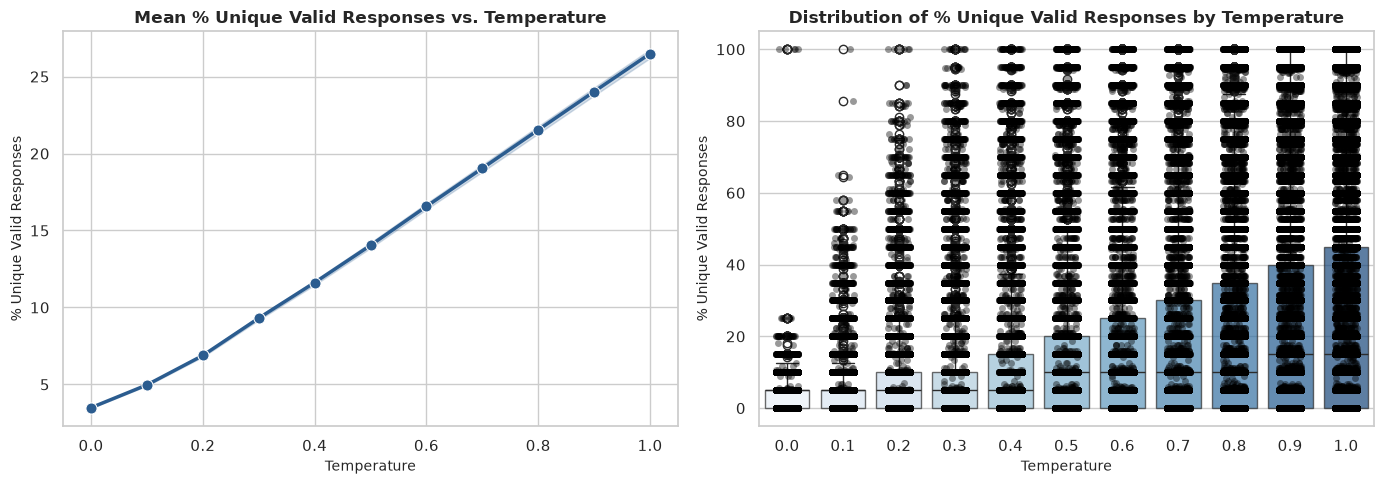

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Mean & Spread Trend Curve across Temperature ---
# Groups by temperature and plots the mean curve with 95% confidence intervals
sns.lineplot(
    data=df,
    x='temperature',
    y='pct_unique_valid',
    marker='o',
    color='#2b5c8f',
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title('Mean % Unique Valid Responses vs. Temperature', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Temperature', fontsize=10)
axes[0].set_ylabel('% Unique Valid Responses', fontsize=10)

# --- Plot 2: Full Distribution per Temperature ---
# Shows medians, quartiles, and individual data points (jitter)
sns.boxplot(
    data=df,
    x='temperature',
    y='pct_unique_valid',
    palette='Blues',
    ax=axes[1],
    boxprops=dict(alpha=0.7)
)
sns.stripplot(
    data=df,
    x='temperature',
    y='pct_unique_valid',
    color='black',
    alpha=0.4,
    jitter=0.2,
    size=5,
    ax=axes[1]
)
axes[1].set_title('Distribution of % Unique Valid Responses by Temperature', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temperature', fontsize=10)
axes[1].set_ylabel('% Unique Valid Responses', fontsize=10)

plt.tight_layout()
plt.show()

In [3]:
df

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,error_log,experiment_index,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid,cleaned_result_output
0,1,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.0,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2..."
1,2,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.1,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2..."
2,3,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.2,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2..."
3,4,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.3,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2..."
4,5,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.4,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473083,473084,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.6,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,6,20,0,30.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":..."
473084,473085,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,8,20,0,40.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":..."
473085,473086,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.8,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,11,20,0,55.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":..."
473086,473087,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.9,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,7,20,0,35.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":..."


/tmp/ipykernel_35758/2137169702.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


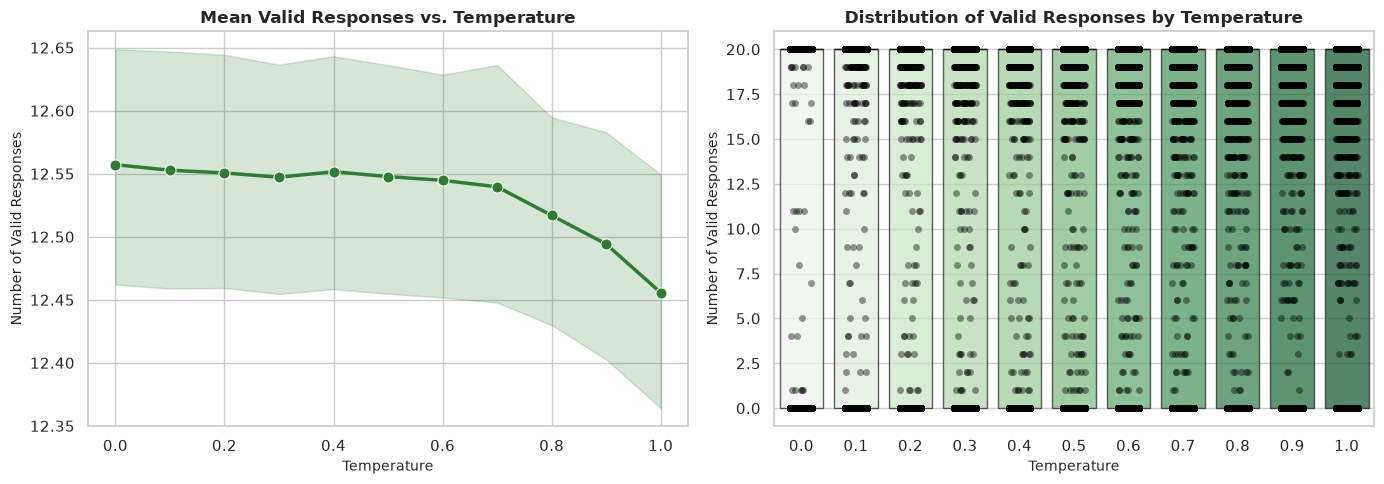

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Mean Trend Curve ---
# Shows the average number of valid responses at each temperature with a 95% CI band
sns.lineplot(
    data=df,
    x='temperature',
    y='num_valid_responses',
    marker='o',
    color='#2e7d32',
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title('Mean Valid Responses vs. Temperature', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Temperature', fontsize=10)
axes[0].set_ylabel('Number of Valid Responses', fontsize=10)

# --- Plot 2: Distribution Boxplot with Data Points ---
# Displays spread, median, quartiles, and individual run data points
sns.boxplot(
    data=df,
    x='temperature',
    y='num_valid_responses',
    palette='Greens',
    ax=axes[1],
    boxprops=dict(alpha=0.7)
)
sns.stripplot(
    data=df,
    x='temperature',
    y='num_valid_responses',
    color='black',
    alpha=0.4,
    jitter=0.2,
    size=5,
    ax=axes[1]
)
axes[1].set_title('Distribution of Valid Responses by Temperature', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temperature', fontsize=10)
axes[1].set_ylabel('Number of Valid Responses', fontsize=10)

plt.tight_layout()
plt.show()

In [19]:
import ast
import json
import pandas as pd
import spot

def parse_predicted_formula(cell_value) -> str:
    """Safely extracts the predicted formula from a dict/list structure."""
    if pd.isna(cell_value):
        return ""
    
    if isinstance(cell_value, str):
        cell_value = cell_value.strip()
        try:
            cell_value = json.loads(cell_value)
        except Exception:
            try:
                cell_value = ast.literal_eval(cell_value)
            except Exception:
                return cell_value

    if isinstance(cell_value, list) and len(cell_value) > 0:
        first_item = cell_value[0]
        if isinstance(first_item, dict):
            return str(first_item.get("Response", "")).strip()
    elif isinstance(cell_value, dict):
        return str(cell_value.get("Response", "")).strip()

    return str(cell_value).strip()


def check_ltl_equivalence(pred_str: str, gt_str: str) -> bool:
    """Checks semantic equivalence between predicted LTL and Spot_LTL ground truth."""
    if not pred_str or not gt_str:
        return False
    try:
        f_pred = spot.formula(pred_str)
        f_gt = spot.formula(gt_str)
        return spot.are_equivalent(f_pred, f_gt)
    except Exception:
        return False


def evaluate_per_temperature(df: pd.DataFrame, 
                             pred_column: str = "result_output", 
                             gt_column: str = "Spot_LTL",
                             prompt_id_column: str = "prompt_id",
                             temp_column: str = "temperature"):
    """
    Evaluates LTL accuracy, oracle pass rates, and semantic diversity grouped by Temperature.
    """
    # 1. Clean LTL strings
    df["clean_pred_ltl"] = df[pred_column].apply(parse_predicted_formula)
    
    # 2. Individual row semantic correctness
    df["is_semantic_correct"] = df.apply(
        lambda row: check_ltl_equivalence(row["clean_pred_ltl"], str(row[gt_column]).strip()), 
        axis=1
    )

    temp_summaries = []
    
    # Group evaluation by each Temperature setting
    for temp, temp_group in df.groupby(temp_column):
        prompt_metrics = []
        
        for prompt_id, p_group in temp_group.groupby(prompt_id_column):
            gt_formula = str(p_group[gt_column].iloc[0]).strip()
            preds = p_group["clean_pred_ltl"].tolist()
            matches = p_group["is_semantic_correct"].tolist()
            
            # Pass@1: Average accuracy across retakes at this specific temperature
            pass_1 = sum(matches) / len(matches) if matches else 0.0
            
            # Pass@N (Oracle): Did ANY retake at this temperature hit ground truth?
            pass_n = any(matches)
            
            # Group into canonical equivalence classes using Spot
            canonical_counts = {}
            syntax_errors = 0
            for p in preds:
                try:
                    canon_str = spot.formula(p).to_str()
                    canonical_counts[canon_str] = canonical_counts.get(canon_str, 0) + 1
                except Exception:
                    syntax_errors += 1

            # Majority Vote accuracy
            if canonical_counts:
                top_canon = max(canonical_counts, key=canonical_counts.get)
                majority_correct = check_ltl_equivalence(top_canon, gt_formula)
            else:
                majority_correct = False
                
            prompt_metrics.append({
                "pass_1": pass_1,
                "pass_n": pass_n,
                "majority_correct": majority_correct,
                "semantic_clusters": len(canonical_counts),
                "syntax_error_rate": syntax_errors / len(preds) if preds else 0.0
            })
            
        p_df = pd.DataFrame(prompt_metrics)
        
        temp_summaries.append({
            "Temperature": temp,
            "Total Prompts": len(p_df),
            "Mean Pass@1 Acc (%)": round(p_df["pass_1"].mean() * 100, 2),
            "Oracle Pass@N Acc (%)": round(p_df["pass_n"].mean() * 100, 2),
            "Majority Vote Acc (%)": round(p_df["majority_correct"].mean() * 100, 2),
            "Avg Clusters / Prompt": round(p_df["semantic_clusters"].mean(), 2),
            "Syntax Error Rate (%)": round(p_df["syntax_error_rate"].mean() * 100, 2)
        })

    summary_df = pd.DataFrame(temp_summaries).sort_values(by="Temperature")
    
    print("=== Per-Temperature Performance Summary ===")
    print(summary_df.to_string(index=False))
    
    return df, summary_df

# Example Usage:
# df = pd.read_csv("your_results.csv")
annotated_df, summary_table = evaluate_per_temperature(
    df, 
    pred_column="result_output", 
    gt_column="Spot_LTL", 
    prompt_id_column="id", 
    temp_column="temperature"
)

=== Per-Temperature Performance Summary ===
 Temperature  Total Prompts  Mean Pass@1 Acc (%)  Oracle Pass@N Acc (%)  Majority Vote Acc (%)  Avg Clusters / Prompt  Syntax Error Rate (%)
         0.0          43008                26.85                  26.85                  26.85                   0.63                  37.22
         0.1          43008                26.80                  26.80                  26.80                   0.63                  37.25
         0.2          43008                26.76                  26.76                  26.76                   0.63                  37.24
         0.3          43008                26.64                  26.64                  26.64                   0.63                  37.26
         0.4          43008                26.65                  26.65                  26.65                   0.63                  37.23
         0.5          43008                26.47                  26.47                  26.47                

In [20]:
annotated_df

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,error_log,experiment_index,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid,cleaned_result_output,clean_pred_ltl,is_semantic_correct
0,1,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.0,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",keep_apple U drop_pear,True
1,2,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.1,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",keep_apple U drop_pear,True
2,3,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.2,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",keep_apple U drop_pear,True
3,4,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.3,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",keep_apple U drop_pear,True
4,5,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.4,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",keep_apple U drop_pear,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473083,473084,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.6,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,6,20,0,30.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",G((prop_1 -> F(prop_2)) & prop_3),False
473084,473085,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,8,20,0,40.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",G((prop_1) -> (prop_2) & (prop_3)),False
473085,473086,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.8,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,11,20,0,55.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",G((prop_1 -> F(prop_2)) & prop_3),False
473086,473087,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.9,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,7,20,0,35.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",G(prop_1 -> (F(prop_2) & prop_3)),False


In [21]:
summary_table

,Temperature,Total Prompts,Mean Pass@1 Acc (%),Oracle Pass@N Acc (%),Majority Vote Acc (%),Avg Clusters / Prompt,Syntax Error Rate (%)
0,0.0,43008,26.85,26.85,26.85,0.63,37.22
1,0.1,43008,26.80,26.80,26.80,0.63,37.25
2,0.2,43008,26.76,26.76,26.76,0.63,37.24
3,0.3,43008,26.64,26.64,26.64,0.63,37.26
4,0.4,43008,26.65,26.65,26.65,0.63,37.23
5,0.5,43008,26.47,26.47,26.47,0.63,37.26
6,0.6,43008,26.32,26.32,26.32,0.63,37.27
7,0.7,43008,26.06,26.06,26.06,0.63,37.31
8,0.8,43008,25.66,25.66,25.66,0.63,37.40
9,0.9,43008,25.43,25.43,25.43,0.62,37.54


In [30]:
import json
sample_row = df[df['temperature'] == 0.8].iloc[0]
retakes = [item['Response'] for item in json.loads(sample_row['result_output'])]

print("Total retakes:", len(retakes))
print("Unique formulas generated:", len(set(retakes)))

Total retakes: 20
Unique formulas generated: 1


In [39]:
df['cleaned_result_output_LTL_only'] = df['cleaned_result_output'].apply(lambda x: [item['Response'] for item in json.loads(x)] if pd.notna(x) else [])

In [40]:
df

,id,original_NL,original_LTL,Spot_LTL,APs,prompt_type,temperature,status,started_at,result_output,error_log,experiment_index,num_unique_valid_responses,num_valid_responses,num_invalid_responses,pct_unique_valid,cleaned_result_output,clean_pred_ltl,is_semantic_correct,cleaned_result_output_LTL_only
0,1,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.0,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",keep_apple U drop_pear,True,"[keep_apple U drop_pear, keep_apple U drop_pea..."
1,2,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.1,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",keep_apple U drop_pear,True,"[keep_apple U drop_pear, keep_apple U drop_pea..."
2,3,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.2,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",keep_apple U drop_pear,True,"[keep_apple U drop_pear, keep_apple U drop_pea..."
3,4,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.3,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",keep_apple U drop_pear,True,"[keep_apple U drop_pear, keep_apple U drop_pea..."
4,5,keep apple until drop pear,"""keep(apple)"" U ""drop(pear)""",keep_apple U drop_pear,"['drop_pear', 'keep_apple']",BASIC,0.4,COMPLETED,NaN,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",NaN,2,1,20,0,5.0,"[{""PROMPTTYPE"": ""BASIC"", ""experiment_index"": 2...",keep_apple U drop_pear,True,"[keep_apple U drop_pear, keep_apple U drop_pea..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473083,473084,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.6,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,6,20,0,30.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",G((prop_1 -> F(prop_2)) & prop_3),False,"[G((prop_1 -> F(prop_2)) & prop_3), G((prop_1 ..."
473084,473085,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.7,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,8,20,0,40.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",G((prop_1) -> (prop_2) & (prop_3)),False,"[G((prop_1) -> (prop_2) & (prop_3)), G((prop_1..."
473085,473086,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.8,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,11,20,0,55.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",G((prop_1 -> F(prop_2)) & prop_3),False,"[G((prop_1 -> F(prop_2)) & prop_3), G(prop_1 -..."
473086,473087,For each time instant in the future it should ...,( G ( prop_1 -> prop_2 ) & prop_3 ),prop_3 & G(prop_1 -> prop_2),"['prop_1', 'prop_2', 'prop_3']",ADARULE,0.9,COMPLETED,NaN,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",NaN,14337,7,20,0,35.0,"[{""PROMPTTYPE"": ""ADARULE"", ""experiment_index"":...",G(prop_1 -> (F(prop_2) & prop_3)),False,"[G(prop_1 -> (F(prop_2) & prop_3)), G(prop_1 -..."
